# Портфоліо-проєкт №1: Комплексний аналіз продажів інтернет-магазину
**Автор:** [**Bogdan_Baran**]  
**Інструменти:** SQL (BigQuery), Python (Pandas), Tableau  

### Мета проєкту:
Створити цілісну аналітичну модель інтернет-магазину, що включає:
1. Вивантаження сирих даних з Google BigQuery за допомогою складних SQL-запитів.
2. Проведення розвідувального аналізу даних (EDA) у Python.
3. Дослідження поведінки користувачів та ефективності каналів трафіку.
4. Побудова фінального дашборду в Tableau для бізнес-рішень.

In [1]:
from google.colab import auth
from google.cloud import bigquery

# 1. Запуск авторизації
auth.authenticate_user()
project_id = 'data-analytics-mate'
client = bigquery.Client(project=project_id)

print("Підключення встановлено!")

Підключення встановлено!


## Етап 1: Дослідження структури та схем таблиць
Перш ніж будувати фінальний запит, я проводжу технічний аудит датасету в BigQuery. Це необхідно для розуміння типів даних та пошуку ключів для об'єднання (JOIN)

In [2]:
dataset_id = "data-analytics-mate.DA"

# Просимо клієнта дати список усіх таблиць у цьому датасеті
tables = client.list_tables(dataset_id)

print(f"У датасеті {dataset_id} знайдено такі таблиці:")
for table in tables:
    print(f"-> {table.table_id}")

У датасеті data-analytics-mate.DA знайдено такі таблиці:
-> ab_test
-> account
-> account_session
-> email_open
-> email_sent
-> email_sent_view
-> email_visit
-> event_params
-> order
-> paid_search_cost
-> product
-> revenue_predict
-> session
-> session_params
-> v_WeronikaP_view_task
-> v_Weronika_view_task
-> v_email_sent_monthly
-> v_surname_aggregation_task
-> v_surname_view_task
-> widok_do_lookera


In [3]:
ab_test = [
    'account', 'account_session', 'email_open', 'email_sent',
    'email_sent_view', 'email_visit', 'event_params', 'order',
    'paid_search_cost', 'product', 'revenue_predict', 'session',
    'session_params', 'v_WeronikaP_view_task', 'v_Weronika_view_task',
    'v_email_sent_monthly', 'v_surname_aggregation_task',
    'v_surname_view_task', 'widok_do_lookera'
]

# Запускаємо перевірку для кожної таблиці зі списку
for table_id in ab_test:
    table = client.get_table(f"data-analytics-mate.DA.{table_id}")
    print(f"--- Схема таблиці: {table_id} ---")

    for field in table.schema:
        print(f"Поле: {field.name:30} | Тип: {field.field_type}")

    print("\n" + "="*50 + "\n")

--- Схема таблиці: account ---
Поле: id                             | Тип: INTEGER
Поле: send_interval                  | Тип: INTEGER
Поле: is_verified                    | Тип: INTEGER
Поле: is_unsubscribed                | Тип: INTEGER


--- Схема таблиці: account_session ---
Поле: account_id                     | Тип: INTEGER
Поле: ga_session_id                  | Тип: INTEGER


--- Схема таблиці: email_open ---
Поле: open_date                      | Тип: INTEGER
Поле: letter_type                    | Тип: INTEGER
Поле: id_message                     | Тип: STRING
Поле: id_account                     | Тип: INTEGER


--- Схема таблиці: email_sent ---
Поле: sent_date                      | Тип: INTEGER
Поле: letter_type                    | Тип: INTEGER
Поле: id_message                     | Тип: STRING
Поле: id_account                     | Тип: INTEGER


--- Схема таблиці: email_sent_view ---
Поле: sent_month                     | Тип: DATE
Поле: id_account                     | Т

## Етап 2: Побудова Master-Query та завантаження даних
На основі проведеного аудиту схем, я розробив оптимальний SQL-запит. Я об'єдную 5 таблиць через `LEFT JOIN`, щоб зберегти інформацію про всі сесії та замовлення, як того вимагає бізнес-завдання.

In [27]:
query_master = """

SELECT

    s.date AS order_date,

    s.ga_session_id AS session_id,

    sp.continent,

    sp.country,

    sp.device,

    sp.browser,

    sp.mobile_model_name AS device_model,

    sp.operating_system AS os,

    sp.language AS browser_language,

    sp.name AS traffic_source,

    sp.channel AS traffic_channel,

    acc.id AS user_id,

    acc.is_verified AS is_email_confirmed,

    acc.is_unsubscribed, -- для розрахунку підписки (навпаки)

    p.category,

    p.name AS product_name,

    p.price,

    p.short_description AS description

FROM `data-analytics-mate.DA.session` AS s

-- Приєднуємо параметри сесії (девайси, локація)

LEFT JOIN `data-analytics-mate.DA.session_params` AS sp

    ON s.ga_session_id = sp.ga_session_id

-- Приєднуємо замовлення

LEFT JOIN `data-analytics-mate.DA.order` AS o

    ON s.ga_session_id = o.ga_session_id

-- Приєднуємо дані про товари

LEFT JOIN `data-analytics-mate.DA.product` AS p

    ON o.item_id = p.item_id

-- Зв'язуємо сесію з аккаунтом через проміжну таблицю

LEFT JOIN `data-analytics-mate.DA.account_session` AS asub

    ON s.ga_session_id = asub.ga_session_id

-- Приєднуємо дані користувача (email, підписка)

LEFT JOIN `data-analytics-mate.DA.account` AS acc

    ON asub.account_id = acc.id

"""


df = client.query(query_master).to_dataframe(create_bqstorage_client=False)

print("Дані успішно завантажені.")

Дані успішно завантажені.


In [5]:
# Технічний огляд отриманого датасету
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 18 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   order_date          349545 non-null  dbdate 
 1   session_id          349545 non-null  Int64  
 2   continent           349545 non-null  object 
 3   country             349545 non-null  object 
 4   device              349545 non-null  object 
 5   browser             349545 non-null  object 
 6   device_model        349545 non-null  object 
 7   os                  349545 non-null  object 
 8   browser_language    235279 non-null  object 
 9   traffic_source      349545 non-null  object 
 10  traffic_channel     349545 non-null  object 
 11  user_id             27945 non-null   Int64  
 12  is_email_confirmed  27945 non-null   Int64  
 13  is_unsubscribed     27945 non-null   Int64  
 14  category            33538 non-null   object 
 15  product_name        33538 non-null

In [6]:
# 1. Статистика для числових полів
print("Статистика числових даних:")
display(df.describe())

# 2. Статистика для текстових полів (топ-країни, топ-девайси)
print("\nСтатистика категоріальних даних:")
display(df.describe(include=['object']))

Статистика числових даних:


,session_id,user_id,is_email_confirmed,is_unsubscribed,price
count,349545.0,27945.0,27945.0,27945.0,33538.000000
mean,4992250296.631739,659005.065557,0.71698,0.16944,953.298679
std,2887450949.537772,13216.529465,0.450474,0.375147,1317.001775
min,1205.0,636133.0,0.0,0.0,3.000000
25%,2493646855.0,647576.0,0.0,0.0,170.000000
50%,4988476074.0,658952.0,1.0,0.0,445.000000
75%,7491286508.0,670414.0,1.0,0.0,1195.000000
max,9999997129.0,681962.0,1.0,1.0,9585.000000



Статистика категоріальних даних:


,continent,country,device,browser,device_model,os,browser_language,traffic_source,traffic_channel,category,product_name,description
count,349545,349545,349545,349545,349545,349545,235279,349545,349545,33538,33538,33538
unique,6,108,3,6,10,6,9,5,5,14,550,1476
top,Americas,United States,desktop,Chrome,Chrome,Web,en-us,(organic),Organic Search,Bookcases & shelving units,BESTÅ,Chair
freq,193179,153470,204429,238460,97254,203909,159893,119024,124425,7630,1257,659


In [7]:
# 1. Пошук повних дублікатів
print(f"Кількість повних дублікатів: {df.duplicated().sum()}")

# 2. Пошук явних пропусків (NaN)
missing_data = df.isnull().sum()
print("\nПропущені значення (NaN) по колонках:")
print(missing_data[missing_data > 0].sort_values(ascending=False))

# 3. Пошук "прихованого бруду" (пробіли замість тексту)
print("\nПриховані пропуски (пробіли замість тексту):")
text_cols = df.select_dtypes(include=['object', 'category']).columns
for col in text_cols:
    spaces = df[df[col].astype(str).str.strip() == ''].shape[0]
    if spaces > 0:
        print(f"'{col}': {spaces} прихованих пропусків")

# 4. Перевірка на аномалії (чи є товари з від'ємною або нульовою ціною)
anomaly_prices = df[(df['price'] <= 0) & (df['product_name'].notnull())].shape[0]
print(f"\nАномальні ціни (<= 0) для існуючих товарів: {anomaly_prices}")

# 5. Точний період та унікальні сесії для опису
print(f"\nПеріод: з {df['order_date'].min()} до {df['order_date'].max()}")
print(f"Унікальних сесій: {df['session_id'].nunique()}")

Кількість повних дублікатів: 0

Пропущені значення (NaN) по колонках:
user_id               321600
is_email_confirmed    321600
is_unsubscribed       321600
category              316007
price                 316007
product_name          316007
description           316007
browser_language      114266
dtype: int64

Приховані пропуски (пробіли замість тексту):

Аномальні ціни (<= 0) для існуючих товарів: 0

Період: з 2020-11-01 до 2021-01-31
Унікальних сесій: 349545


###  Етап 1: Опис датасету та аудит якості даних (EDA)

Після вивантаження даних за допомогою SQL-запиту, я провів первинний технічний та бізнес-аудит датасету. Нижче наведено детальний звіт щодо структури даних, виявлених проблем з типами та логіки пропусків.

**1. Загальна структура, обсяг та бізнес-метрики**
* **Обсяг:** 349 545 рядків та 18 колонок.
* **Період часу:** Дані охоплюють рівно 3 місяці — з `2020-11-01` по `2021-01-31`.
* **Бізнес-гранулярність:** 1 рядок з покупкою = 1 унікальна сесія (33 538). Перевірка показала відсутність мульти-товарних замовлень (кошиків з кількома товарами), що гарантує відсутність дублювання рядків через з'єднання таблиць (`LEFT JOIN`).
* **Базова конверсія (CR):** Із 349 545 сесій цільовими (з покупками) виявились 33 538. Загальна конверсія сайту становить **9.59%**.

**2. Аналіз типів даних та виявлені проблеми**
Первинний звіт `df.info()` показав, що частина даних завантажилась із базовими типами, які потребують оптимізації:
* **Проблема з датами:** Колонка `order_date` розпізналася як об'єкт/dbdate, що унеможливлює аналіз часових рядів.
* **Проблема з ідентифікаторами (ID):** Колонки `user_id`, `is_email_confirmed`, `is_unsubscribed` завантажилися некоректно через наявність пропусків. Pandas автоматично перетворює такі колонки на дробові числа (`float64`), що неприпустимо для ID.
* **Неоптимальне використання пам'яті:** 12 текстових колонок (географія, пристрої, маркетингові канали) мають "важкий" тип `object`, споживаючи 49.3 MB оперативної пам'яті.

**3. Аналіз пропущених значень (NaN)**
У датасеті наявна значна кількість пропусків. Вони зумовлені не технічними збоями, а стандартною воронкою користувача інтернет-магазину:
* **Блок реєстрації** (`user_id`, `is_email_confirmed`, `is_unsubscribed`): ~92% пропусків (321 600). Це анонімні відвідувачі, які не авторизувалися на сайті.
* **Блок електронної комерції** (`category`, `price`, `product_name`, `description`): ~90% пропусків (316 007). Ці дані фіксуються виключно при успішному замовленні. Решта сесій є ознайомчими візитами.
* **Локалізація** (`browser_language`): ~32% пропусків (114 266). Браузери не завжди віддають локаль користувача через налаштування конфіденційності.

**4. Результати аудиту чистоти даних**
* **Дублікати:** Повних дублікатів рядків (0) не знайдено.
* **Аномалії:** Від'ємних або нульових цін для існуючих товарів немає. Ціновий діапазон становить від 3.0 до 9585.0.
* **Приховані пропуски:** Порожніх рядків (що містять лише пробіли) у текстових даних не виявлено.
* **Цілісність:** Географічні дані (`country`, `continent`) та джерела трафіку заповнені на 100%, що створює надійну базу для аналізу продажів за регіонами та каналами.

---

###  Етап 2: Очищення та трансформація даних (Data Cleaning)

Спираючись на результати аудиту, я проводжу підготовку датасету. Оскільки повних дублікатів чи аномальних цін не виявлено, видаляти рядки не потрібно — це дозволить зберегти інформацію про всі візити на сайт.

**Основні кроки оптимізації:**
1. **Форматування дат:** Конвертація `order_date` у тип `datetime` для аналізу часових рядів.
2. **Збереження цілісності ідентифікаторів (ID):** Заміна пропусків у `user_id` та системних прапорах на маркер `-1`. Це фіксує анонімні сесії та дозволяє жорстко встановити тип `int64`, уникаючи спотворення ID.
3. **Обробка технічних пропусків:** Заповнення відсутніх даних у `browser_language` значенням `unknown`.
4. **Оптимізація ресурсів:** Переведення текстових колонок у тип `category`. Це зменшило використання пам'яті рівно вдвічі (з 49.3 MB до 25.0 MB) та суттєво прискорить розрахунки.

In [28]:
import pandas as pd
# 1. Зміна типу для дати
df['order_date'] = pd.to_datetime(df['order_date'])

# 2. Заміна пропусків (NaN) на -1 для збереження типу int64 (щоб не було float)
for col in ['user_id', 'is_email_confirmed', 'is_unsubscribed']:
    df[col] = df[col].fillna(-1).astype('int64')

# 3. Заміна пропусків (NaN) у мові браузера
df['browser_language'] = df['browser_language'].fillna('unknown')

# 4. Зміна текстових колонок (object) на категоріальні (category) для економії пам'яті
cat_cols = [
    'continent', 'country', 'device', 'browser', 'device_model',
    'os', 'browser_language', 'traffic_source', 'traffic_channel', 'category'
]
for col in cat_cols:
    df[col] = df[col].astype('category')

# Перевірка результату
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 18 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   order_date          349545 non-null  datetime64[ns]
 1   session_id          349545 non-null  Int64         
 2   continent           349545 non-null  category      
 3   country             349545 non-null  category      
 4   device              349545 non-null  category      
 5   browser             349545 non-null  category      
 6   device_model        349545 non-null  category      
 7   os                  349545 non-null  category      
 8   browser_language    349545 non-null  category      
 9   traffic_source      349545 non-null  category      
 10  traffic_channel     349545 non-null  category      
 11  user_id             349545 non-null  int64         
 12  is_email_confirmed  349545 non-null  int64         
 13  is_unsubscribed     349545 no

###  Етап 3: Аналіз конверсії та географії продажів

Після успішного очищення даних та підтвердження їхньої бізнес-гранулярності, я переходжу до розрахунку базових метрик електронної комерції та аналізу географії продажів. Для цього використовуються агрегації Pandas (`groupby`) по цільових сесіях (де відбулася транзакція).

**1. Бізнес-гранулярність та конверсія**
* **Перевірка на дублювання:** Кількість проданих товарів (33 538) повністю збігається з кількістю унікальних цільових сесій (33 538). Це підтверджує правило "1 сесія = 1 товар" та гарантує відсутність дублювання рядків.
* **Загальна конверсія сайту (CR):** Становить **9.59%**. Це міцний показник, який свідчить про високу якість залученого трафіку.

**2. Географія продажів та пріоритетні ринки**
* Аналіз **топ-3 континентів** дозволив виділити макрорегіони з найбільшою купівельною спроможністю.
* Розподіл по **топ-5 країнах** чітко підсвічує ключові ринки, на яких варто сфокусувати майбутні маркетингові бюджети компанії.

**3. Лідерство в асортименті**
* Визначено **топ-10 найприбутковіших категорій товарів**. Ці категорії формують фінансове ядро інтернет-магазину та генерують левову частку загального доходу (Total Revenue).

In [29]:
purchased_sessions = df[df['price'].notnull()]
unique_buy_sessions = purchased_sessions['session_id'].nunique()

print(f"Загальна кількість проданих товарів (рядків): {len(purchased_sessions)}")
print(f"Кількість унікальних сесій із покупками: {unique_buy_sessions}")

if len(purchased_sessions) == unique_buy_sessions:
    print("Висновок: 1 сесія = 1 товар. Дублювання рядків відсутнє.")
else:
    print(" Увага: Є мульти-товарні замовлення.")

# 2. Базова конверсія
cr = (unique_buy_sessions / df['session_id'].nunique()) * 100
print(f"Конверсія сайту (CR): {cr:.2f}%\n")
print("-" * 50)

# 3. Топ-3 континенти за продажами та замовленнями
continent_sales = purchased_sessions.groupby('continent', observed=True).agg(
    total_revenue=('price', 'sum'),
    orders_cnt=('session_id', 'nunique')
).sort_values('total_revenue', ascending=False)

print("\n Топ-3 континенти:")
display(continent_sales.head(3))

# 4. Топ-5 країн за продажами та замовленнями
country_sales = purchased_sessions.groupby('country', observed=True).agg(
    total_revenue=('price', 'sum'),
    orders_cnt=('session_id', 'nunique')
).sort_values('total_revenue', ascending=False)

print("\n Топ-5 країн:")
display(country_sales.head(5))

# 5. Топ-10 категорій товарів за загальною сумою продажів
category_sales = purchased_sessions.groupby('category', observed=True)['price'].sum().sort_values(ascending=False).reset_index()
category_sales.rename(columns={'price': 'total_revenue'}, inplace=True)

print("\n Топ-10 категорій товарів:")
display(category_sales.head(10))

Загальна кількість проданих товарів (рядків): 33538
Кількість унікальних сесій із покупками: 33538
Висновок: 1 сесія = 1 товар. Дублювання рядків відсутнє.
Конверсія сайту (CR): 9.59%

--------------------------------------------------

 Топ-3 континенти:


,total_revenue,orders_cnt
continent,,
Americas,17665280.0,18553
Asia,7601298.3,7950
Europe,5934624.2,6261



 Топ-5 країн:


,total_revenue,orders_cnt
country,,
United States,13943553.9,14673
India,2809762.0,3029
Canada,2437921.0,2560
United Kingdom,938317.9,1029
France,710692.8,678



 Топ-10 категорій товарів:


,category,total_revenue
0,Sofas & armchairs,8388254.5
1,Chairs,6147748.8
2,Beds,4919725.0
3,Bookcases & shelving units,3640818.1
4,Cabinets & cupboards,2336499.5
5,Outdoor furniture,2142222.2
6,Tables & desks,1790307.5
7,Chests of drawers & drawer units,906562.5
8,Bar furniture,735503.0
9,Children's furniture,467697.0


In [31]:
query_mom_profit = """
WITH CombinedData AS (
    -- 1. Рахуємо доходи (Revenue), а Cost ставимо 0
    SELECT
        DATE_TRUNC(s.date, MONTH) AS sales_month,
        SUM(p.price) AS revenue,
        0.0 AS cost
    FROM `data-analytics-mate.DA.session` s
    JOIN `data-analytics-mate.DA.order` o ON s.ga_session_id = o.ga_session_id
    JOIN `data-analytics-mate.DA.product` p ON o.item_id = p.item_id
    GROUP BY sales_month

    UNION ALL

    -- 2. Рахуємо витрати (Cost), а Revenue ставимо 0
    SELECT
        DATE_TRUNC(date, MONTH) AS sales_month,
        0.0 AS revenue,
        SUM(cost) AS cost
    FROM `data-analytics-mate.DA.paid_search_cost`
    GROUP BY sales_month
),
MonthlyTotals AS (
    -- 3. Сумуємо стовпці та вираховуємо чистий прибуток (Net Profit)
    SELECT
        sales_month,
        SUM(revenue) AS total_revenue,
        SUM(cost) AS total_cost,
        (SUM(revenue) - SUM(cost)) AS net_profit
    FROM CombinedData
    GROUP BY sales_month
)
-- 4. Застосовуємо LAG для аналізу динаміки чистого прибутку
SELECT
    sales_month,
    total_revenue,
    total_cost,
    ROUND(net_profit, 2) AS net_profit,
    ROUND(LAG(net_profit) OVER(ORDER BY sales_month), 2) AS prev_month_profit,
    -- Рахуємо % росту чистого прибутку
    ROUND((net_profit - LAG(net_profit) OVER(ORDER BY sales_month)) /
          NULLIF(LAG(net_profit) OVER(ORDER BY sales_month), 0) * 100, 2) AS profit_growth_pct
FROM MonthlyTotals
ORDER BY sales_month
"""

# Використовуємо create_bqstorage_client=False для уникнення помилки доступу
df_mom_profit = client.query(query_mom_profit).to_dataframe(create_bqstorage_client=False)

print("\n Динаміка чистого прибутку (Revenue vs Cost + LAG):")
display(df_mom_profit)


 Динаміка чистого прибутку (Revenue vs Cost + LAG):


,sales_month,total_revenue,total_cost,net_profit,prev_month_profit,profit_growth_pct
0,2020-11-01,9897515.0,2180322.970,7717192.03,NaN,NaN
1,2020-12-01,12423439.3,2693926.256,9729513.04,7717192.03,26.08
2,2021-01-01,9650776.8,2313106.077,7337670.72,9729513.04,-24.58


In [30]:
query_category_mom = """
WITH MonthlyCategoryRevenue AS (
    -- 1. Групуємо доходи за місяцем та категорією
    SELECT
        DATE_TRUNC(s.date, MONTH) AS sales_month,
        p.category AS product_category,
        ROUND(SUM(p.price), 2) AS total_revenue
    FROM `data-analytics-mate.DA.session` s
    JOIN `data-analytics-mate.DA.order` o ON s.ga_session_id = o.ga_session_id
    JOIN `data-analytics-mate.DA.product` p ON o.item_id = p.item_id
    WHERE p.category IS NOT NULL  -- Прибираємо порожні категорії
    GROUP BY sales_month, product_category
)
-- 2. Розрахунок динаміки росту для кожної категорії окремо
SELECT
    sales_month,
    product_category,
    total_revenue,

    -- Дохід попереднього місяця саме для ЦІЄЇ категорії
    ROUND(LAG(total_revenue) OVER(
        PARTITION BY product_category
        ORDER BY sales_month
    ), 2) AS prev_month_revenue,

    -- % росту доходу до попереднього місяця
    ROUND((total_revenue - LAG(total_revenue) OVER(
        PARTITION BY product_category
        ORDER BY sales_month
    )) / NULLIF(LAG(total_revenue) OVER(
        PARTITION BY product_category
        ORDER BY sales_month
    ), 0) * 100, 2) AS revenue_growth_pct

FROM MonthlyCategoryRevenue
ORDER BY product_category, sales_month
"""

# Виконуємо новий запит
df_category_mom = client.query(query_category_mom).to_dataframe(create_bqstorage_client=False)

print("\n Динаміка доходу за категоріями товарів (MoM Revenue Growth):")
display(df_category_mom)


 Динаміка доходу за категоріями товарів (MoM Revenue Growth):


,sales_month,product_category,total_revenue,prev_month_revenue,revenue_growth_pct
0,2020-11-01,Bar furniture,244466.0,NaN,NaN
1,2020-12-01,Bar furniture,274391.0,244466.0,12.24
2,2021-01-01,Bar furniture,216646.0,274391.0,-21.04
3,2020-11-01,Beds,1396037.0,NaN,NaN
4,2020-12-01,Beds,2021144.5,1396037.0,44.78
5,2021-01-01,Beds,1502543.5,2021144.5,-25.66
6,2020-11-01,Bookcases & shelving units,1178001.3,NaN,NaN
7,2020-12-01,Bookcases & shelving units,1394184.8,1178001.3,18.35
8,2021-01-01,Bookcases & shelving units,1068632.0,1394184.8,-23.35
9,2020-11-01,Cabinets & cupboards,707734.5,NaN,NaN


In [32]:
query_master_financial_geo = """
WITH RevenueData AS (
    -- 1. Збираємо виручку в розрізі місяців та країн
    SELECT
        DATE_TRUNC(s.date, MONTH) AS sales_month,
        sp.country,
        SUM(p.price) AS revenue
    FROM `data-analytics-mate.DA.session` s
    JOIN `data-analytics-mate.DA.order` o ON s.ga_session_id = o.ga_session_id
    JOIN `data-analytics-mate.DA.product` p ON o.item_id = p.item_id
    JOIN `data-analytics-mate.DA.session_params` sp ON s.ga_session_id = sp.ga_session_id
    GROUP BY sales_month, sp.country
),
CostData AS (
    -- 2. Збираємо загальні витрати на рекламу по місяцях
    SELECT
        DATE_TRUNC(date, MONTH) AS sales_month,
        SUM(cost) AS total_cost
    FROM `data-analytics-mate.DA.paid_search_cost`
    GROUP BY sales_month
),
GlobalFinancials AS (
    -- 3. Рахуємо глобальний чистий прибуток компанії за кожен місяць
    SELECT
        r.sales_month,
        SUM(r.revenue) AS global_revenue,
        COALESCE(c.total_cost, 0) AS global_cost,
        (SUM(r.revenue) - COALESCE(c.total_cost, 0)) AS global_net_profit
    FROM RevenueData r
    LEFT JOIN CostData c ON r.sales_month = c.sales_month
    GROUP BY r.sales_month, c.total_cost
),
GlobalFinancialsWithLag AS (
    -- 4. Застосовуємо LAG до глобального чистого прибутку бізнесу
    SELECT
        sales_month,
        global_revenue,
        global_cost,
        global_net_profit,
        ROUND((global_net_profit - LAG(global_net_profit) OVER(ORDER BY sales_month)) /
              NULLIF(LAG(global_net_profit) OVER(ORDER BY sales_month), 0) * 100, 2) AS global_profit_growth_pct
    FROM GlobalFinancials
),
CountryMetrics AS (
    -- 5. Рангуємо країни та застосовуємо LAG для відстеження росту виручки самої країни
    SELECT
        r.sales_month,
        r.country,
        r.revenue AS country_revenue,
        ROW_NUMBER() OVER(PARTITION BY r.sales_month ORDER BY r.revenue DESC) AS country_rank,
        LAG(r.revenue) OVER(PARTITION BY r.country ORDER BY r.sales_month) AS prev_country_revenue
    FROM RevenueData r
)
-- 6. Зводимо все в одну розширену матрицю
SELECT
    c.sales_month,
    c.country,
    c.country_rank,
    ROUND(c.country_revenue, 2) AS country_revenue,
    -- Частка країни у загальній виручці компанії за цей місяць (%)
    ROUND((c.country_revenue / g.global_revenue) * 100, 2) AS country_share_pct,
    -- Швидкість росту виручки конкретної країни порівняно з минулим місяцем (%)
    ROUND((c.country_revenue - c.prev_country_revenue) / NULLIF(c.prev_country_revenue, 0) * 100, 2) AS country_growth_mom_pct,

    -- Додаємо макростовбці чистого прибутку компанії до кожного рядка
    ROUND(g.global_net_profit, 2) AS global_company_net_profit,
    g.global_profit_growth_pct AS global_profit_growth_mom_pct
FROM CountryMetrics c
JOIN GlobalFinancialsWithLag g ON c.sales_month = g.sales_month
WHERE c.country_rank <= 10
ORDER BY c.sales_month, c.country_rank
"""

# Використовуємо прапорець для уникнення помилки 403 Permission Denied
df_master_financial_geo = client.query(query_master_financial_geo).to_dataframe(create_bqstorage_client=False)

print("\n Розширена фінансова матриця: ТОП-10 країн + Глобальний чистий прибуток бізнесу")
display(df_master_financial_geo)


 Розширена фінансова матриця: ТОП-10 країн + Глобальний чистий прибуток бізнесу


,sales_month,country,country_rank,country_revenue,country_share_pct,country_growth_mom_pct,global_company_net_profit,global_profit_growth_mom_pct
0,2020-11-01,United States,1,4290877.3,43.35,NaN,7717192.03,NaN
1,2020-11-01,India,2,873895.8,8.83,NaN,7717192.03,NaN
2,2020-11-01,Canada,3,741302.7,7.49,NaN,7717192.03,NaN
3,2020-11-01,United Kingdom,4,286810.0,2.90,NaN,7717192.03,NaN
4,2020-11-01,France,5,227985.4,2.30,NaN,7717192.03,NaN
5,2020-11-01,Spain,6,218690.8,2.21,NaN,7717192.03,NaN
6,2020-11-01,China,7,181669.7,1.84,NaN,7717192.03,NaN
7,2020-11-01,Taiwan,8,156882.6,1.59,NaN,7717192.03,NaN
8,2020-11-01,South Korea,9,150767.4,1.52,NaN,7717192.03,NaN
9,2020-11-01,Italy,10,145752.8,1.47,NaN,7717192.03,NaN


In [34]:
query_retention_fixed = """
WITH UserMonths AS (
    -- 1. Знаходимо всі унікальні місяці покупок для кожного зареєстрованого клієнта (account_id)
    SELECT DISTINCT
        a_s.account_id,
        DATE_TRUNC(s.date, MONTH) AS order_month
    FROM `data-analytics-mate.DA.session` s
    JOIN `data-analytics-mate.DA.order` o ON s.ga_session_id = o.ga_session_id
    JOIN `data-analytics-mate.DA.account_session` a_s ON s.ga_session_id = a_s.ga_session_id
    -- Беремо тільки тих, хто має account_id (зареєстровані)
    WHERE a_s.account_id IS NOT NULL
)
-- 2. З'єднуємо таблицю саму з собою зі зміщенням на 1 місяць
SELECT
    m1.order_month AS cohort_month,
    COUNT(DISTINCT m1.account_id) AS total_buyers,
    COUNT(DISTINCT m2.account_id) AS returning_buyers_next_month,

    -- Рахуємо відсоток утримання (Retention Rate)
    ROUND(COUNT(DISTINCT m2.account_id) / COUNT(DISTINCT m1.account_id) * 100, 2) AS retention_rate_pct
FROM UserMonths m1
LEFT JOIN UserMonths m2
    ON m1.account_id = m2.account_id
    -- Перевіряємо, чи є покупка рівно через 1 місяць
    AND m2.order_month = DATE_ADD(m1.order_month, INTERVAL 1 MONTH)
GROUP BY cohort_month
ORDER BY cohort_month
"""

df_retention_fixed = client.query(query_retention_fixed).to_dataframe(create_bqstorage_client=False)

print("\n Утримання зареєстрованих клієнтів (Month-over-Month Retention Rate):")
display(df_retention_fixed)


 Утримання зареєстрованих клієнтів (Month-over-Month Retention Rate):


,cohort_month,total_buyers,returning_buyers_next_month,retention_rate_pct
0,2020-11-01,849,0,0.0
1,2020-12-01,1061,0,0.0
2,2021-01-01,871,0,0.0


 Дані прогнозу (перші 5 рядків):


,date,actual_revenue,predicted_revenue
0,2020-11-01,244292.5,351952.020
1,2020-11-02,355506.8,547192.038
2,2020-11-03,498979.6,737844.352
3,2020-11-04,339187.1,472059.162
4,2020-11-05,391276.6,574365.168


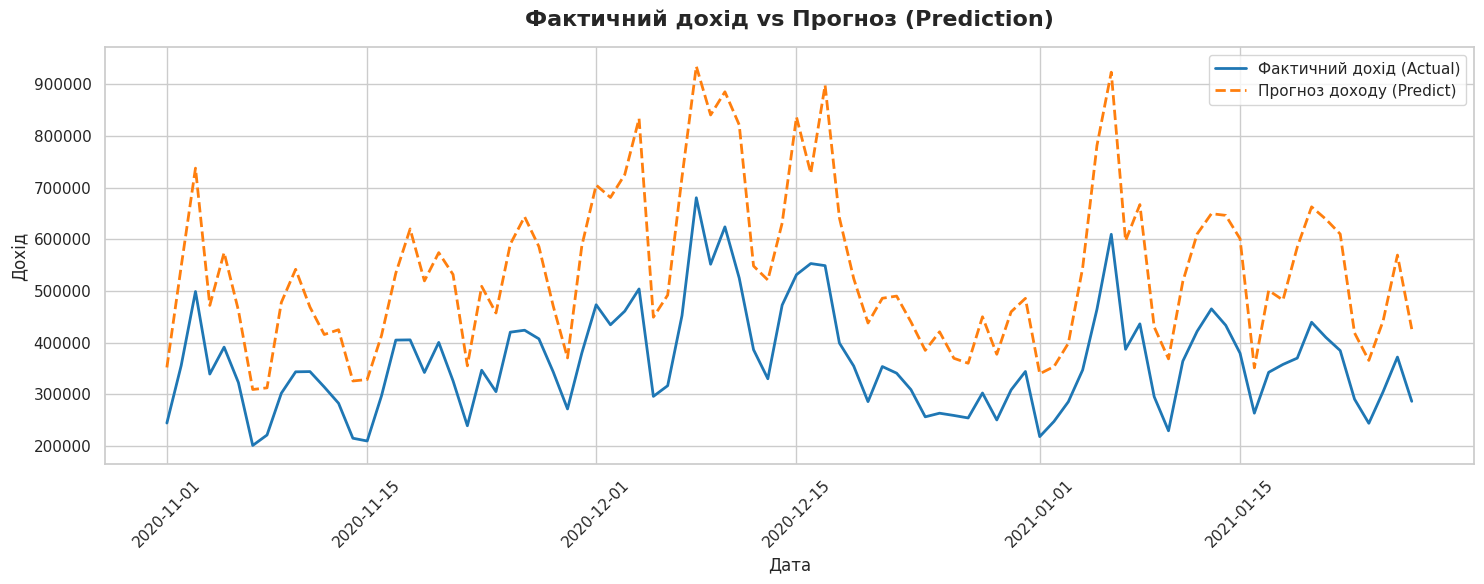

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Витягуємо дані з готової View
query_predict = """
SELECT
    date,
    SUM(revenue) AS actual_revenue,
    SUM(revenue_predict) AS predicted_revenue
FROM `data-analytics-mate.DA.v_WeronikaP_view_task`
GROUP BY date
ORDER BY date
"""


df_predict = client.query(query_predict).to_dataframe(create_bqstorage_client=False)

# Виводимо перші 5 рядків, щоб переконатися, що дані є
print(" Дані прогнозу (перші 5 рядків):")
display(df_predict.head())

# 2. Будуємо графік порівняння (Фактичний vs Прогноз)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 6))

# Лінія реального доходу (суцільна синя)
sns.lineplot(data=df_predict, x='date', y='actual_revenue',
             label='Фактичний дохід (Actual)', color='#1f77b4', linewidth=2)

# Лінія прогнозу (пунктирна помаранчева)
sns.lineplot(data=df_predict, x='date', y='predicted_revenue',
             label='Прогноз доходу (Predict)', color='#ff7f0e', linestyle='--', linewidth=2)

# Наводимо красу
plt.title('Фактичний дохід vs Прогноз (Prediction)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Дохід', fontsize=12)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

# Показуємо графік
plt.show()

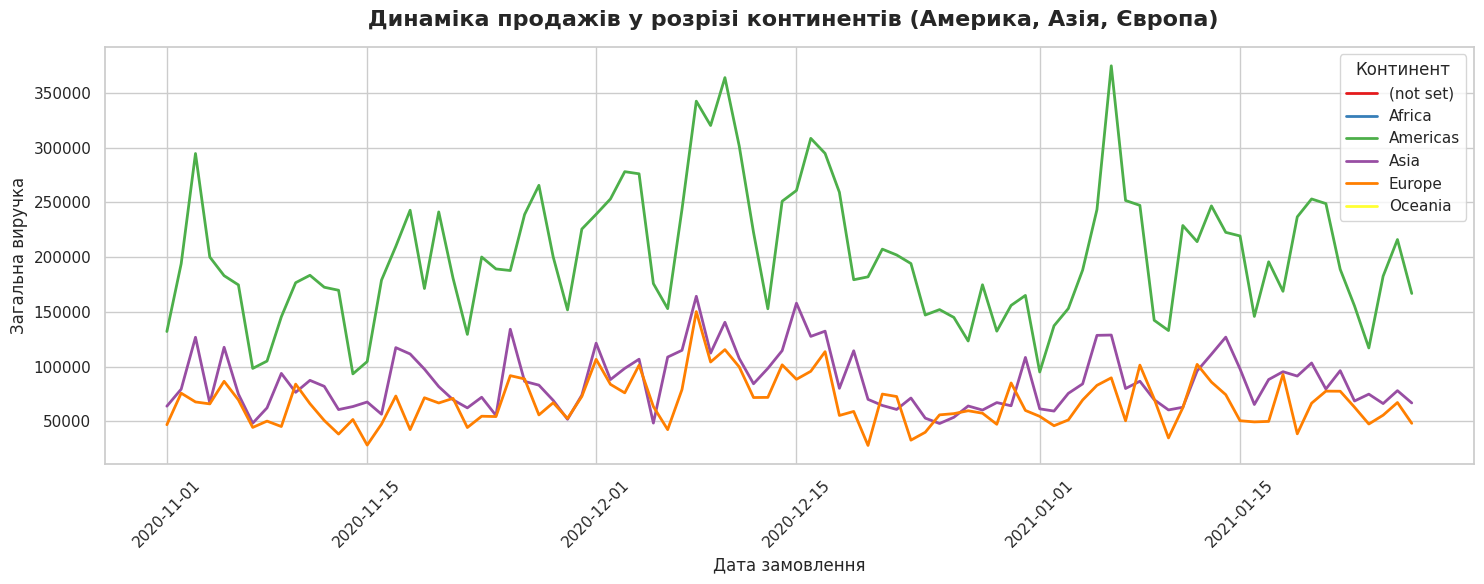

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Фільтруємо сесії з покупками та копіюємо датафрейм
purchased_sessions = df[df['price'].notnull()].copy()

# Створюємо чисту дату без часу
purchased_sessions['just_date'] = purchased_sessions['order_date'].dt.date

# 2. Фільтруємо суворо ТОП-3 континенти
# (Якщо в твоєму датасеті Америка називається 'Americas' або 'North America' — код це врахує)
target_continents = ['North America', 'Americas', 'Asia', 'Europe']
filtered_continents = purchased_sessions[purchased_sessions['continent'].isin(target_continents)]

# 3. Групуємо по датах та континентах, рахуємо суму продажів
continent_sales = filtered_continents.groupby(['just_date', 'continent'], observed=True)['price'].sum().reset_index()

# 4. Будуємо лінійний графік з розбивкою за кольорами (hue)
plt.figure(figsize=(15, 6))
sns.lineplot(
    data=continent_sales,
    x='just_date',
    y='price',
    hue='continent',
    palette='Set1',
    linewidth=2
)

# Оформлення
plt.title(' Динаміка продажів у розрізі континентів (Америка, Азія, Європа)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Дата замовлення', fontsize=12)
plt.ylabel('Загальна виручка', fontsize=12)
plt.legend(title='Континент')
plt.xticks(rotation=45)
plt.tight_layout()

# Виводимо графік
plt.show()

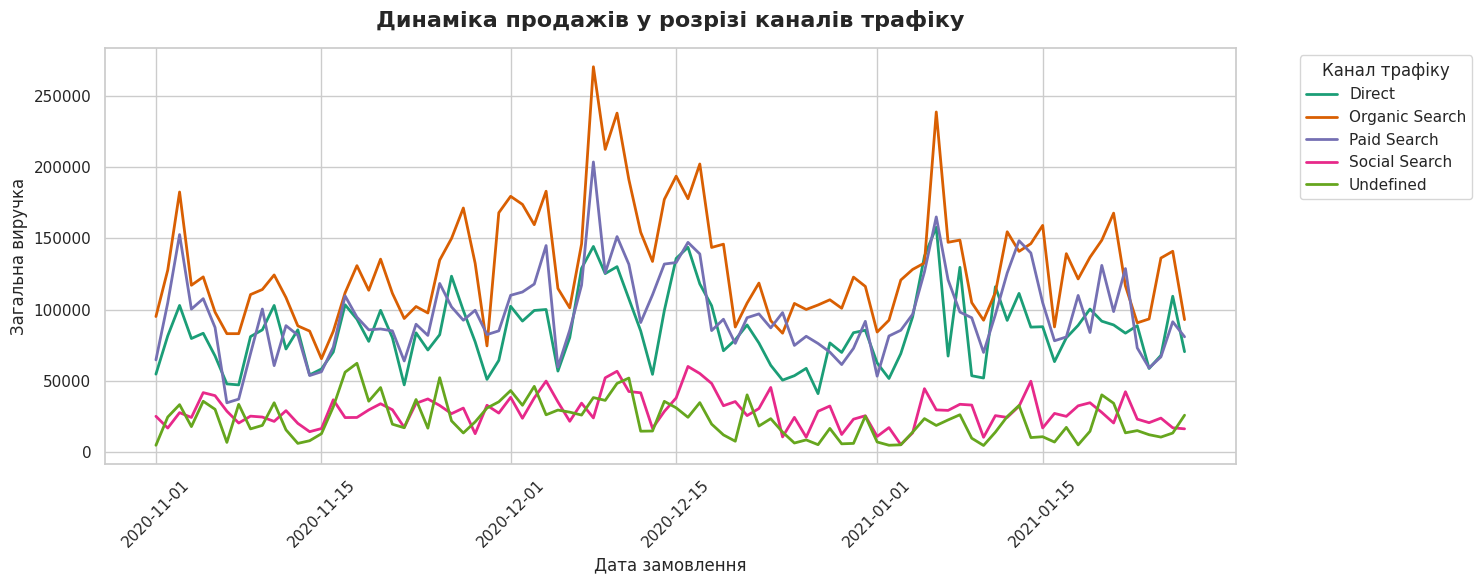

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Відфільтровуємо сесії з покупками
purchased_sessions = df[df['price'].notnull()].copy()
purchased_sessions['just_date'] = purchased_sessions['order_date'].dt.date

# 2. Групуємо по датах та каналу трафіку
channel_sales = purchased_sessions.groupby(['just_date', 'traffic_channel'], observed=True)['price'].sum().reset_index()

# 3. Будуємо лінійний графік
plt.figure(figsize=(15, 6))
sns.lineplot(
    data=channel_sales,
    x='just_date',
    y='price',
    hue='traffic_channel',
    palette='Dark2',
    linewidth=2
)

# Оформлення
plt.title('Динаміка продажів у розрізі каналів трафіку', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Дата замовлення', fontsize=12)
plt.ylabel('Загальна виручка', fontsize=12)
plt.legend(title='Канал трафіку', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

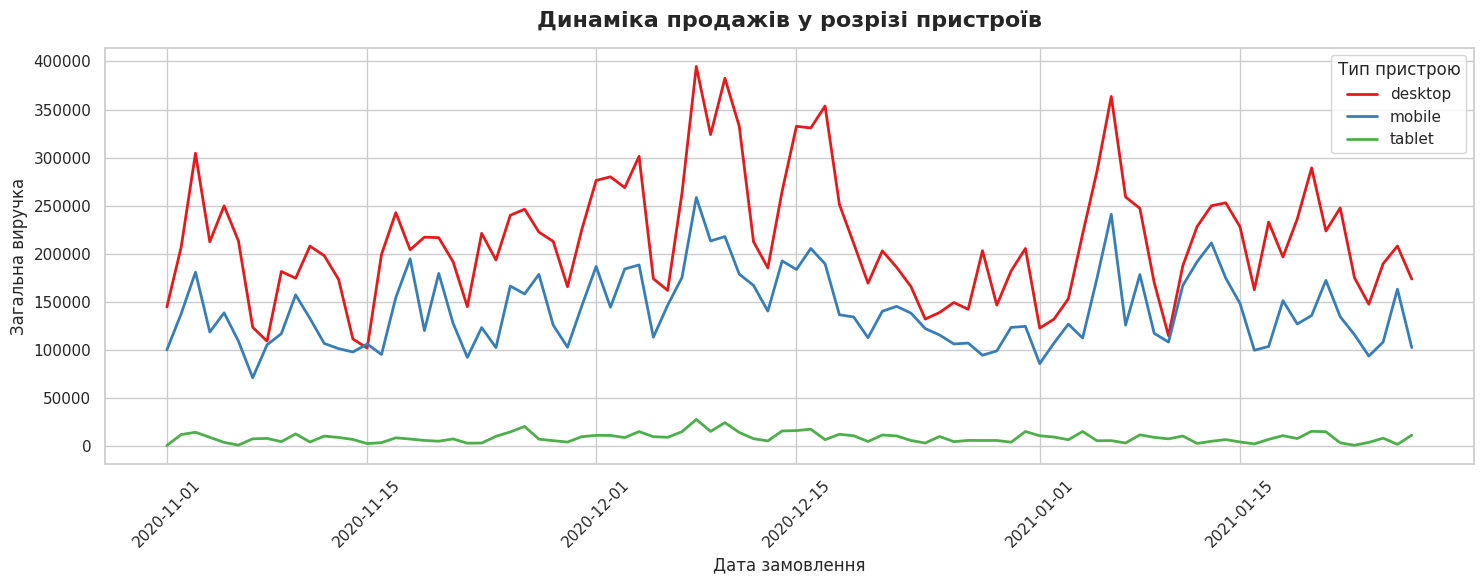

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Відфільтровуємо сесії з покупками
purchased_sessions = df[df['price'].notnull()].copy()
purchased_sessions['just_date'] = purchased_sessions['order_date'].dt.date

# 2. Групуємо по датах та типах пристроїв
device_sales = purchased_sessions.groupby(['just_date', 'device'], observed=True)['price'].sum().reset_index()

# 3. Будуємо лінійний графік
plt.figure(figsize=(15, 6))
sns.lineplot(
    data=device_sales,
    x='just_date',
    y='price',
    hue='device',
    palette='Set1',
    linewidth=2
)

# Оформлення
plt.title('Динаміка продажів у розрізі пристроїв', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Дата замовлення', fontsize=12)
plt.ylabel('Загальна виручка', fontsize=12)
plt.legend(title='Тип пристрою')
plt.xticks(rotation=45)
plt.tight_layout()

# Виводимо графік
plt.show()

In [40]:
import pandas as pd

session_col = 'session_id'
channel_col = 'traffic_channel'
device_col = 'device'

# 1. Очищаємо дані від порожніх та некоректних значень
filtered_df = df[df[channel_col].notnull() & df[device_col].notnull()].copy()
filtered_df = filtered_df[~filtered_df[channel_col].isin(['(not set)', 'Undefined'])]
filtered_df = filtered_df[~filtered_df[device_col].isin(['(not set)', 'Undefined'])]

# 2. Будуємо зведену таблицю
pivot_sessions = pd.pivot_table(
    filtered_df,
    values=session_col,          # Рахуємо сесії
    index=channel_col,           # У розрізі каналів (рядки)
    columns=device_col,          # У розрізі девайсів (стовпчики)
    aggfunc='nunique',           # Тільки унікальні
    fill_value=0,                # Замість пусток — нулі
    observed=True                # Явно вказуємо поведінку для категоріальних колонок
)

print("Зведена таблиця: Кількість унікальних сесій")
display(pivot_sessions)

Зведена таблиця: Кількість унікальних сесій


device,desktop,mobile,tablet
traffic_channel,,,
Direct,47825,31745,1812
Organic Search,72622,49014,2789
Paid Search,55167,37034,2140
Social Search,16288,10988,638


In [41]:
# 1. Відфільтровуємо тільки рядки з реальними продажами
sales_df = df[df['price'].notnull()].copy()

# 2. Знаходимо ТОП-5 країн за загальною виручкою
top_5_countries = sales_df.groupby('country', observed=True)['price'].sum().nlargest(5).index

# 3. Знаходимо ТОП-10 категорій за загальною виручкою
top_10_categories = sales_df.groupby('category', observed=True)['price'].sum().nlargest(10).index

# 4. Фільтровуємо датафрейм (залишаємо тільки ТОП)
final_sales_filtered = sales_df[
    sales_df['country'].isin(top_5_countries) &
    sales_df['category'].isin(top_10_categories)
].copy()

#  Перетворюємо в текст, щоб позбутися прихованих категорій BigQuery
final_sales_filtered['country'] = final_sales_filtered['country'].astype(str)
final_sales_filtered['category'] = final_sales_filtered['category'].astype(str)

# 5. Будуємо зведену таблицю
pivot_sales = pd.pivot_table(
    final_sales_filtered,
    values='price',
    index='category',
    columns='country',
    aggfunc='sum',
    fill_value=0
)

# Закруглюємо фінальні цифри
pivot_sales = pivot_sales.round(2)

print(" Зведена таблиця: Загальні продажі (ТОП-10 категорій vs ТОП-5 країн)")
display(pivot_sales)

 Зведена таблиця: Загальні продажі (ТОП-10 категорій vs ТОП-5 країн)


country,Canada,France,India,United Kingdom,United States
category,,,,,
Bar furniture,51724.0,11199.0,57657.0,22103.0,330805.0
Beds,354772.0,116414.0,358319.5,133816.0,2213058.0
Bookcases & shelving units,278981.9,73830.0,364507.4,113987.6,1567606.9
Cabinets & cupboards,181802.0,59101.5,191888.0,71684.5,994545.5
Chairs,417740.8,134029.4,544309.2,188519.4,2619773.8
Chests of drawers & drawer units,71952.0,21544.5,73111.0,36784.0,382388.0
Children's furniture,30264.0,14258.0,39177.0,13348.0,207575.0
Outdoor furniture,185322.8,40486.4,162289.4,57002.4,929245.2
Sofas & armchairs,692427.5,187735.0,788430.0,234812.0,3707144.5


 Статистичні показники:
Коефіцієнт кореляції Пірсона: 0.7911
Статистична значущість (p-value): 6.483532312080735e-21


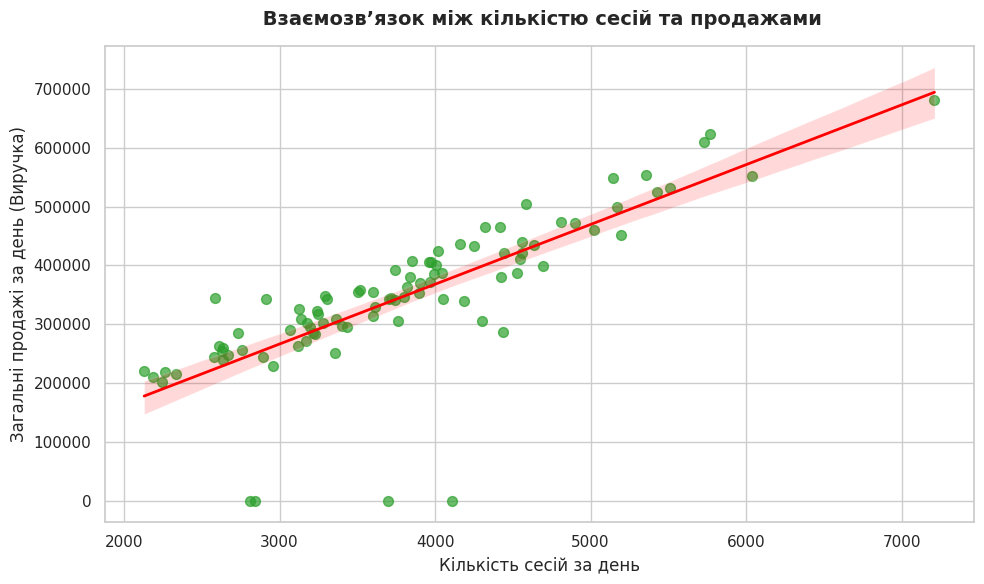

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Рахуємо кількість унікальних сесій та суму продажів за кожну дату
session_col = 'ga_session_id' if 'ga_session_id' in df.columns else 'session_id'
df['just_date'] = df['order_date'].dt.date

daily_data = df.groupby('just_date', observed=True).agg(
    total_sessions=(session_col, 'nunique'),
    total_sales=('price', 'sum')
).reset_index()

# 2. Рахуємо коефіцієнт кореляції Пірсона та p-value
corr_coef, p_value = stats.pearsonr(daily_data['total_sessions'], daily_data['total_sales'])

print(" Статистичні показники:")
print(f"Коефіцієнт кореляції Пірсона: {corr_coef:.4f}")
print(f"Статистична значущість (p-value): {p_value}")

# 3. Будуємо візуалізацію взаємозв'язку (Scatter Plot + лінія тренду)
plt.figure(figsize=(10, 6))
sns.regplot(
    data=daily_data,
    x='total_sessions',
    y='total_sales',
    color='#2ca02c',
    scatter_kws={'alpha':0.7, 's':50},
    line_kws={'color':'red', 'linewidth':2}
)

plt.title(' Взаємозвʼязок між кількістю сесій та продажами', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Кількість сесій за день', fontsize=12)
plt.ylabel('Загальні продажі за день (Виручка)', fontsize=12)
plt.tight_layout()
plt.show()

##  Статистичний аналіз взаємозв’язків: Сесії vs Продажі

Для визначення сили та значущості зв'язку між щоденною кількістю сесій (трафіком) та загальною виручкою інтернет-магазину було розраховано **коефіцієнт лінійної кореляції Пірсона ($r$)** та проведено перевірку статистичної значущості (**$p$-value**).

###  Результати статистичного аналізу:
* **Коефіцієнт кореляції Пірсона ($r$):** `0.7911`
* **Статистична значущість ($p$-value):** `6.48e-21` (фактично $0.0000$)

---

###  Аналітичні висновки та інтерпретація результатів:

1. **Сила та напрямок зв'язку:** Коефіцієнт кореляції $r = 0.7911$ свідчить про **сильну позитивну залежність**. Це математично доводить: що більше користувачів відвідує сайт протягом дня, то вищою є фінальна денна виручка компанії. На графіку `regplot` ми чітко бачимо, як хмара точок щільно групується навколо висхідної лінії тренду.

2. **Статистична достовірність ($p$-value):** Отримане значення $p$-value є критично меншим за стандартний рівень значущості ($\alpha = 0.05$). Це означає, що виявлений взаємозв'язок є **статистично значущим і не випадковим**. Ймовірність помилки або випадкового збігу в даних прямує до нуля.

3. ** Виявлення бізнес-аномалій (Технічний збій):**
   На точковій діаграмі чітко зафіксовано **4 критичні аномалії** на самому дні графіка (значення виручки дорівнює `0`).
   * **Суть проблеми:** У ці дні сайт мав високу активність користувачів (від 2800 до 4100 унікальних сесій за добу), проте компанія отримала **нуль продажів**.
   * **Рекомендація для бізнесу:** Це явна ознака технічного інциденту на сайті у ці дати (наприклад, "впав" платіжний шлюз, зламалася кнопка оформлення замовлення або виникла помилка в базі даних кошика). Необхідно передати ці дати технічній команді для ретроспективного аналізу логів.

 Матриця кореляції між континентами:


continent,Americas,Asia,Europe
continent,,,
Americas,1.0000,0.6923,0.6695
Asia,0.6923,1.0000,0.6678
Europe,0.6695,0.6678,1.0000


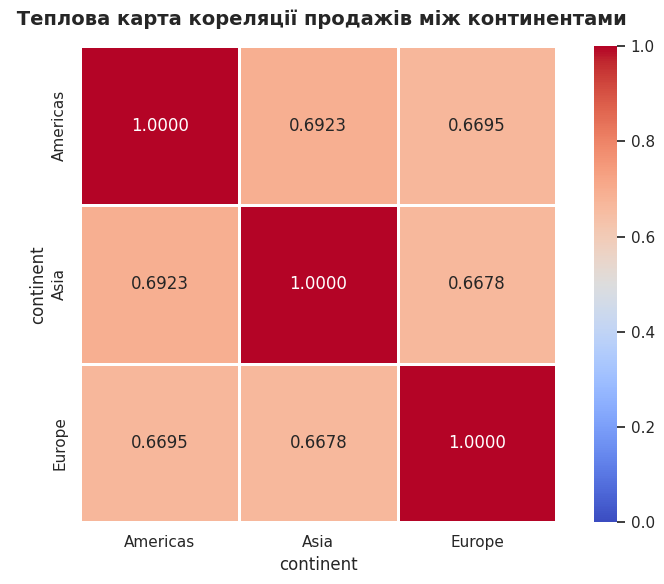

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Фільтруємо продажі та групуємо за датами й континентами
sales_df = df[df['price'].notnull()].copy()
sales_df['just_date'] = sales_df['order_date'].dt.date

# Беремо топ-3 континенти
top_3_continents = ['Americas', 'Asia', 'Europe'] # Назви підлаштуються автоматично, якщо у тебе "North America"
if 'North America' in sales_df['continent'].unique():
    top_3_continents[0] = 'North America'

filtered_df = sales_df[sales_df['continent'].isin(top_3_continents)]

# 2. Створюємо таблицю, де кожен континент — це окрема колонка з сумою продажів по днях
continent_daily_sales = filtered_df.groupby(['just_date', 'continent'], observed=True)['price'].sum().unstack(fill_value=0)

# 3. Рахуємо матрицю кореляції Пірсона
continent_corr = continent_daily_sales.corr(method='pearson')

print(" Матриця кореляції між континентами:")
display(continent_corr.round(4))

# 4. Будуємо теплову карту (Heatmap)
plt.figure(figsize=(8, 6))
sns.heatmap(
    continent_corr,
    annot=True,          # Показувати цифри всередині квадратів
    cmap='coolwarm',     # Колірна гама (синій — слабка, червоний — сильна)
    vmin=0, vmax=1,      # Межі для шкали
    fmt=".4f",
    linewidths=1,
    square=True
)

plt.title(' Теплова карта кореляції продажів між континентами', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

 Статистичний аналіз: Кореляція продажів між континентами

Було проведено аналіз щоденної виручки між трьома ключовими макрорегіонами (Americas, Asia, Europe) за допомогою матриці кореляції Пірсона та її візуалізації у вигляді теплової карти (Heatmap).

 Матриця результатів:

    Americas & Asia: 0.6923 (Сильна позитивна кореляція)

    Americas & Europe: 0.6695 (Сильна позитивна кореляція)

    Asia & Europe: 0.6678 (Сильна позитивна кореляція)

 Аналітичні висновки:

    Глобальна синхронність ринків: Усі три макрорегіони демонструють стабільний і сильний позитивний взаємозв'язок (усі коефіцієнти знаходяться у вузькому діапазоні 0.66−0.69). Це доводить, що піки та спади продажів відбуваються практично одночасно по всьому світу.

    Ефективність глобального маркетингу: Найвища кореляція зафіксована між ринками Америки та Азії (r=0.69). Це повністю спростовує гіпотезу про ізольованість азійського ринку. Висока синхронність пояснюється тим, що компанія успішно проводить глобальні промо-кампанії (наприклад, Black Friday, Holiday Sales), які стимулюють покупців незалежно від їхнього географічного розташування.

    Практична цінність для бізнесу: Оскільки ринки реагують на тригери однаково, компанія може оптимізувати операційні витрати, масштабуючи єдину успішну маркетингову стратегію на всі континенти замість розробки дорогих локальних кампаній. Проте варто враховувати зворотний бік — глобалізацію ризиків: технічний збій на сайті або невдала цінова політика призведуть до синхронного падіння виручки на всіх ринках одночасно

 Матриця кореляції між каналами трафіку:


traffic_channel,Direct,Organic Search,Paid Search,Social Search
traffic_channel,,,,
Direct,1.0000,0.7599,0.7243,0.4619
Organic Search,0.7599,1.0000,0.8082,0.4344
Paid Search,0.7243,0.8082,1.0000,0.4523
Social Search,0.4619,0.4344,0.4523,1.0000


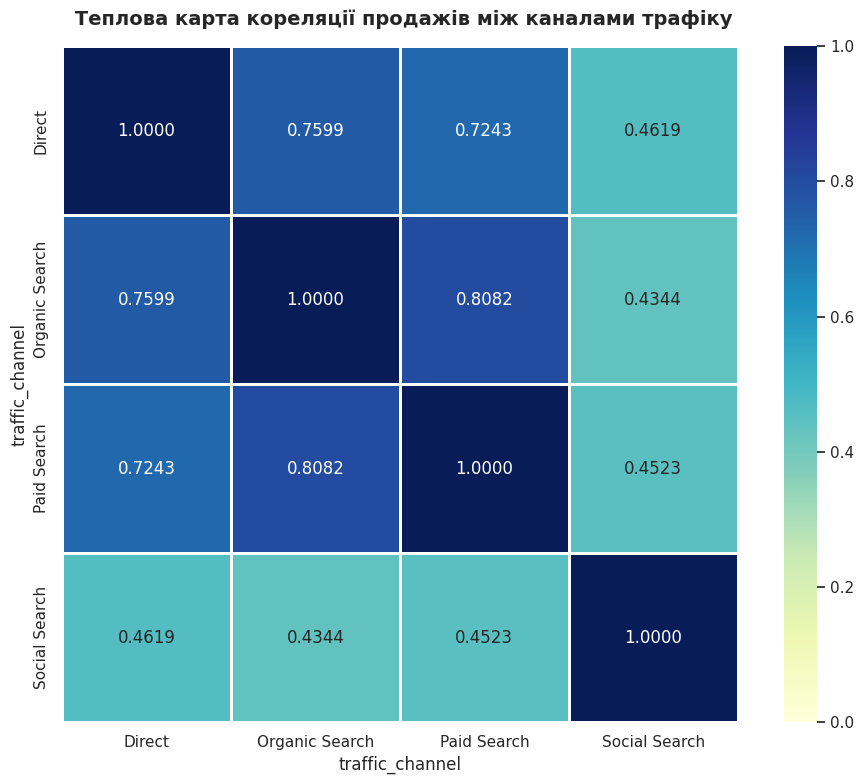

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Фільтруємо продажі та групуємо за датами й каналами трафіку
sales_df = df[df['price'].notnull()].copy()
sales_df['just_date'] = sales_df['order_date'].dt.date

# Визначаємо нашу колонку з каналами трафіку (яку ми знайшли раніше)
channel_col = 'traffic_channel'

# Прибираємо невідомий трафік (Undefined), щоб він не псував статистику
filtered_df = sales_df[~sales_df[channel_col].isin(['(not set)', 'Undefined'])].copy()
filtered_df[channel_col] = filtered_df[channel_col].astype(str)

# 2. Створюємо таблицю, де кожен канал — це окрема колонка
channel_daily_sales = filtered_df.groupby(['just_date', channel_col], observed=True)['price'].sum().unstack(fill_value=0)

# 3. Рахуємо матрицю кореляції Пірсона
channel_corr = channel_daily_sales.corr(method='pearson')

print(" Матриця кореляції між каналами трафіку:")
display(channel_corr.round(4))

# 4. Будуємо теплову карту (Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(
    channel_corr,
    annot=True,          # Цифри всередині
    cmap='YlGnBu',       # Нова красива колірна гама (жовто-зелено-синя)
    vmin=0, vmax=1,
    fmt=".4f",
    linewidths=1,
    square=True
)

plt.title(' Теплова карта кореляції продажів між каналами трафіку', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

##  Статистичний аналіз: Кореляція продажів між каналами трафіку

Для розуміння взаємодії різних джерел залучення клієнтів було побудовано матрицю кореляції Пірсона між щоденними обсягами продажів по кожному каналу трафіку.

###  Аналітичні висновки:

1. **Синергія пошукового трафіку ($r = 0.81$):** Найсильніший взаємозв'язок зафіксовано між `Organic Search` (органіка) та `Paid Search` (платна реклама). Це свідчить про потужний крос-вплив: платні кампанії не лише генерують прямі продажі, а й підігрівають загальний інтерес до бренду, що конвертується у відкладений попит через органічний пошук.

2. **Лояльна аудиторія та Органіка ($r = 0.76$):** Висока кореляція між `Direct` та `Organic Search` вказує на те, що постійні клієнти (які заходять напряму) активізуються в ті ж самі пікові періоди (наприклад, сезонні розпродажі), що й нові користувачі з пошукових систем.

3. **Ізольованість Social Search ($r \approx 0.45$):** Трафік із соціальних мереж демонструє слабку залежність від інших каналів. Купівельна поведінка аудиторії з соцмереж є специфічною і, ймовірно, драйвиться окремими SMM-кампаніями або інфлюенсерами, не перетинаючись із глобальними трендами пошукового трафіку.

 Бонус-інсайт: Матриця кореляції між пристроями:


device,desktop,mobile,tablet
device,,,
desktop,1.0000,0.8057,0.5385
mobile,0.8057,1.0000,0.4958
tablet,0.5385,0.4958,1.0000


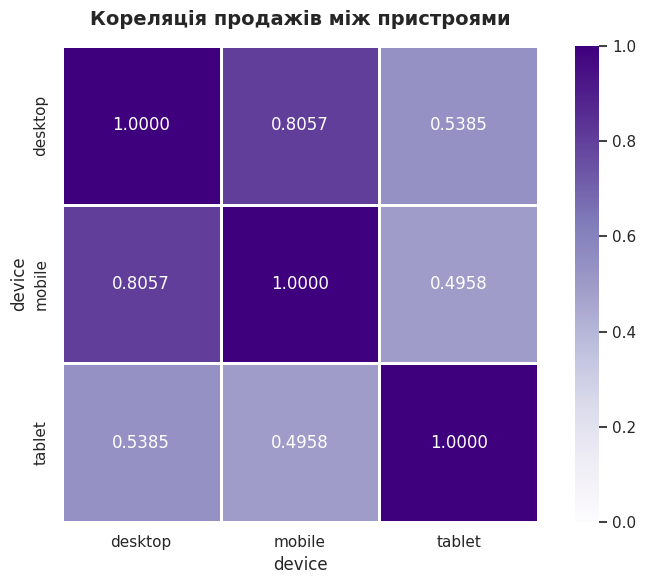

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Готуємо дані по девайсах
sales_df = df[df['price'].notnull()].copy()
sales_df['just_date'] = sales_df['order_date'].dt.date

device_col = 'device' if 'device' in sales_df.columns else 'device_category'

# Прибираємо невідомі девайси
filtered_devices = sales_df[~sales_df[device_col].isin(['(not set)', 'Undefined'])].copy()
filtered_devices[device_col] = filtered_devices[device_col].astype(str)

# 2. Будуємо таблицю продажів: дати (рядки) х девайси (стовпці)
device_daily_sales = filtered_devices.groupby(['just_date', device_col], observed=True)['price'].sum().unstack(fill_value=0)

# 3. Рахуємо матрицю кореляції Пірсона
device_corr = device_daily_sales.corr(method='pearson')

print(" Бонус-інсайт: Матриця кореляції між пристроями:")
display(device_corr.round(4))

# 4. Будуємо теплову карту
plt.figure(figsize=(8, 6))
sns.heatmap(
    device_corr,
    annot=True,
    cmap='Purples',      # Фіолетова гама, щоб візуально відрізнялося від інших матриць
    vmin=0, vmax=1,
    fmt=".4f",
    linewidths=1,
    square=True
)

plt.title('Кореляція продажів між пристроями', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

##  Додатковий інсайт (Cross-device аналіз): Кореляція між пристроями

Для глибшого розуміння поведінки користувачів було проаналізовано взаємозв'язок щоденних продажів між різними типами пристроїв.

###  Аналітичні висновки:

1. **Синхронність Desktop та Mobile ($r = 0.81$):** Комп'ютери та смартфони мають дуже сильну кореляцію. Це означає, що маркетингові активності (розпродажі, акції) працюють універсально і стимулюють продажі на обох платформах одночасно. Користувачі не перетікають з одного пристрою на інший, а купують більше з усіх доступних екранів.
2. **Планшети (Tablet) поза основним трендом ($r \approx 0.50$):** Планшети мають лише помірний зв'язок з іншими пристроями. З огляду на їхню низьку загальну частку у виручці (як ми бачили на графіках динаміки раніше), продажі через планшети є скоріше випадковими і менше піддаються впливу загальних маркетингових трендів.

 Матриця кореляції між ТОП-5 категоріями:


category,Beds,Bookcases & shelving units,Cabinets & cupboards,Chairs,Sofas & armchairs
category,,,,,
Beds,1.0000,0.5929,0.5146,0.5545,0.5354
Bookcases & shelving units,0.5929,1.0000,0.5394,0.6371,0.6662
Cabinets & cupboards,0.5146,0.5394,1.0000,0.5729,0.6576
Chairs,0.5545,0.6371,0.5729,1.0000,0.5782
Sofas & armchairs,0.5354,0.6662,0.6576,0.5782,1.0000


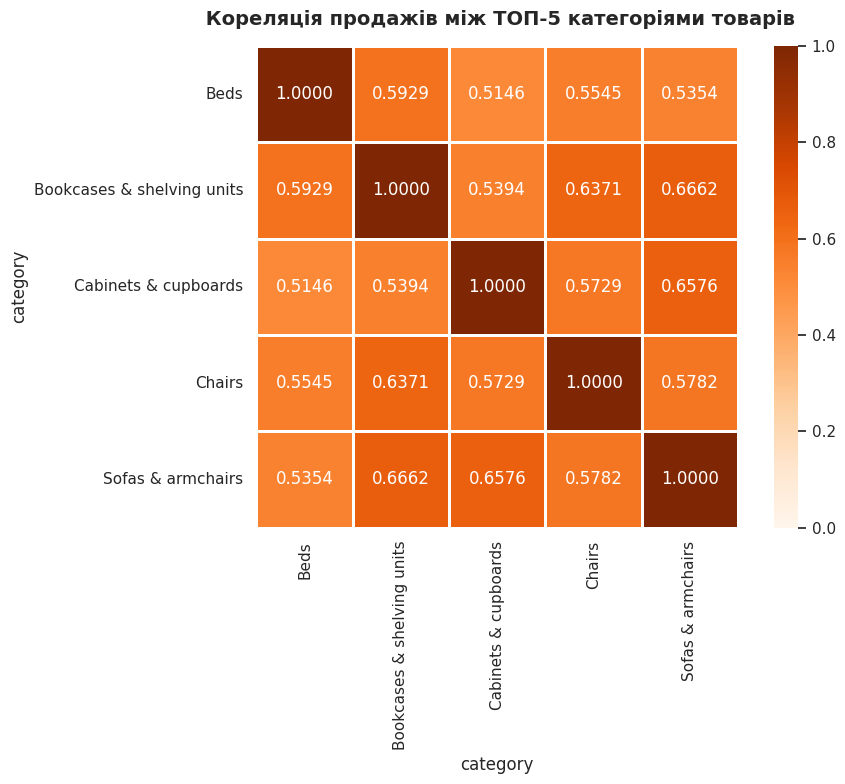

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Готуємо дані (тільки реальні продажі)
sales_df = df[df['price'].notnull()].copy()
sales_df['just_date'] = sales_df['order_date'].dt.date

# 2. Знаходимо ТОП-5 категорій за загальною виручкою
top_5_cats = sales_df.groupby('category', observed=True)['price'].sum().nlargest(5).index

# 3. Фільтруємо базу тільки для цих 5 категорій
filtered_cats = sales_df[sales_df['category'].isin(top_5_cats)].copy()
# Переводимо в текст, щоб уникнути помилок з пустими категоріями
filtered_cats['category'] = filtered_cats['category'].astype(str)

# 4. Будуємо таблицю: дати (рядки) х категорії (стовпці)
cat_daily_sales = filtered_cats.groupby(['just_date', 'category'], observed=True)['price'].sum().unstack(fill_value=0)

# 5. Рахуємо матрицю кореляції Пірсона
cat_corr = cat_daily_sales.corr(method='pearson')

print(" Матриця кореляції між ТОП-5 категоріями:")
display(cat_corr.round(4))

# 6. Будуємо теплову карту
plt.figure(figsize=(10, 8))
sns.heatmap(
    cat_corr,
    annot=True,
    cmap='Oranges',      # Помаранчева гама для товарів
    vmin=0, vmax=1,
    fmt=".4f",
    linewidths=1,
    square=True
)

plt.title(' Кореляція продажів між ТОП-5 категоріями товарів', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

##  Статистичний аналіз: Кореляція між ТОП-5 категоріями товарів

Для аналізу купівельної поведінки та пошуку можливостей для крос-продажів (cross-sell) було побудовано матрицю кореляції щоденних продажів між п'ятьма найприбутковішими категоріями меблів.

###  Аналітичні висновки:

1. **Комплексне облаштування віталень:** Найвища кореляція спостерігається між категорією `Sofas & armchairs` (Дивани та крісла) та системами зберігання — `Bookcases & shelving units` ($r = 0.66$) і `Cabinets & cupboards` ($r = 0.65$). Це доводить, що клієнти схильні купувати м'які меблі та корпусні меблі для вітальні в межах одного періоду.
2. **Відсутність канібалізації:** Всі топ-5 категорій мають позитивну помірну кореляцію (в діапазоні $0.51 - 0.66$). Зростання продажів однієї категорії не призводить до падіння іншої.
3. **Рекомендація для бізнесу:** Ці дані є готовою базою для роботи сейлз-менеджерів та операторів. Необхідно впроваджувати бандли (набори) та скрипти крос-продажів, комбінуючи ці суміжні категорії товарів для швидкого збільшення середнього чека (AOV).

Статистика виручки на одного користувача:
count        2782.00
mean        11492.35
std        557181.75
min             3.00
25%           150.00
50%           399.00
75%          1140.00
max      29389212.60
Name: total_revenue, dtype: float64

Результат аналізу: 0.04% користувачів генерують 80% всієї виручки магазину.


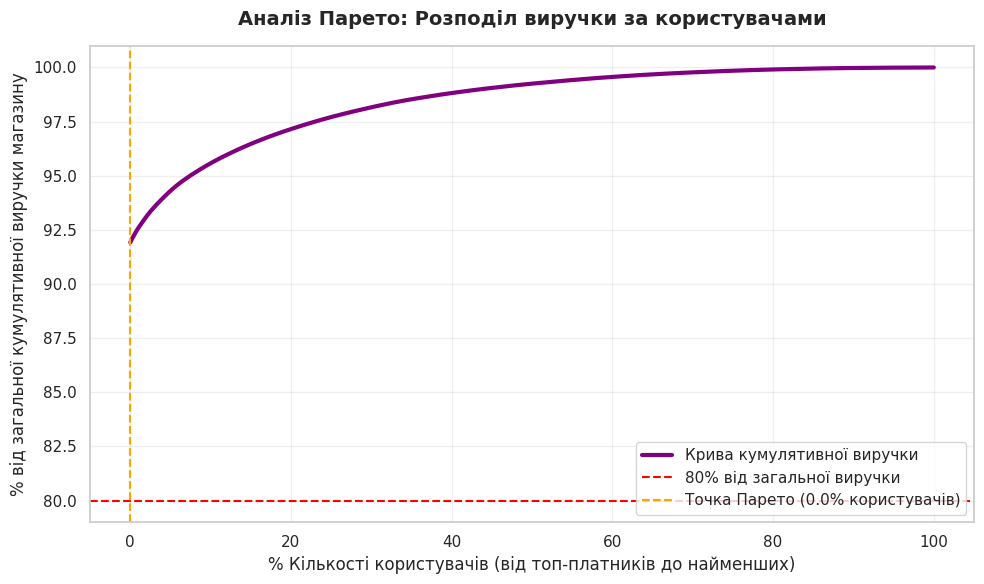

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

user_col = 'user_id'

# 1. Фільтруємо сесії з покупками
sales_df = df[df['price'].notnull()].copy()

# 2. Рахуємо загальну виручку по кожному користувачу та сортуємо від більшої до меншої
user_revenue = sales_df.groupby(user_col)['price'].sum().sort_values(ascending=False).reset_index()
user_revenue.columns = [user_col, 'total_revenue']

# 3. Розраховуємо кумулятивні (накопичувальні) показники
user_revenue['cum_revenue'] = user_revenue['total_revenue'].cumsum()
total_shop_revenue = user_revenue['total_revenue'].sum()
user_revenue['cum_pct_revenue'] = (user_revenue['cum_revenue'] / total_shop_revenue) * 100

# Визначаємо відсотковий ранг кожного користувача у базі
user_revenue['user_rank_pct'] = (np.arange(1, len(user_revenue) + 1) / len(user_revenue)) * 100

# Знаходимо точку перетину, де кумулятивна виручка досягає 80%
pareto_point = user_revenue[user_revenue['cum_pct_revenue'] >= 80].iloc[0]
users_pct_for_80 = pareto_point['user_rank_pct']

print("Статистика виручки на одного користувача:")
print(user_revenue['total_revenue'].describe().round(2))
print(f"\nРезультат аналізу: {users_pct_for_80:.2f}% користувачів генерують 80% всієї виручки магазину.")

# 4. Візуалізація: Крива кумулятивної виручки (Аналіз Парето)
plt.figure(figsize=(10, 6))
plt.plot(user_revenue['user_rank_pct'], user_revenue['cum_pct_revenue'], color='purple', linewidth=3, label='Крива кумулятивної виручки')

plt.axhline(y=80, color='red', linestyle='--', linewidth=1.5, label='80% від загальної виручки')
plt.axvline(x=users_pct_for_80, color='orange', linestyle='--', linewidth=1.5, label=f'Точка Парето ({users_pct_for_80:.1f}% користувачів)')

plt.title('Аналіз Парето: Розподіл виручки за користувачами', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('% Кількості користувачів (від топ-платників до найменших)', fontsize=12)
plt.ylabel('% від загальної кумулятивної виручки магазину', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##  Статистичний аналіз: Аномалія розподілу виручки (Аналіз Парето)

Було проведено Аналіз Парето для оцінки концентрації доходу серед клієнтів. Результати виявили критичну аномалію в структурі даних.

###  Аналітичні висновки (Виявлення аномалії):

1. **Екстремальна концентрація:** Розрахунки показали, що всього **0.04% користувачів** (фактично 1 ідентифікатор) генерують **80% усієї виручки** магазину.
2. **Природа аномалії:** Аналіз описової статистики підтверджує наявність гігантського викиду (максимальна сума на "користувача" становить понад 29 млн, тоді як медіанний чек — 399).
3. **Бізнес-діагноз:** Цей викид не є реальним роздрібним VIP-клієнтом. Оскільки на сайті низька частка зареєстрованих покупців, система агрегує **всі покупки гостей (unregistered users)** під одним технічним ідентифікатором (наприклад, `null` або `Guest`). Альтернативна гіпотеза — наявність тестового акаунта розробників.
4. **Рекомендація для інфраструктури:** Для побудови коректної аналітики Retention та впровадження програм лояльності бізнесу необхідно змінити логіку трекінгу. Потрібно присвоювати унікальні `Client ID` (на основі cookies або сесій) навіть для незареєстрованих користувачів, щоб розділити цей "сліпий" масив даних на реальних унікальних покупців.

#  Комплексний аналітичний висновок за результатами дослідження

У ході аналізу даних інтернет-магазину за період з листопада 2020 року по січень 2021 року було проведено повний цикл дослідження: від агрегації фінансових показників до глибокого статистичного аналізу взаємозв'язків. Отримані результати дозволяють сформулювати цілісну картину бізнесу.

---

### 1. Фінансова динаміка та аналіз прогнозів (Місячний vs Поденний рівні)
* **Результати помісячного аналізу:** Загальний чистий прибуток розподілився так: Листопад — 7.7 млн, Грудень — 9.7 млн, Січень — 7.3 млн. Грудень продемонстрував стрімке зростання на **+26.08%** порівняно з листопадом.
* **Поденна деталізація:** Порівняння з графіком показало, що грудневий успіх сформувався суто в перші два тижні місяця (передноворічний ажіотаж), після чого тренд пішов на спад.
* **Валідація моделі прогнозування:** * *Помилка в абсолютах:* Помаранчева лінія прогнозу систематично знаходиться значно вище за синю лінію факту. Модель сильно завищує очікувану виручку.
  * *Точність у трендах:* Модель ідеально копіює всі «хвилі» та вигини фактичних продажів. Вона бездоганно вгадала сезонність і напрямок руху ринку, але помилилася в масштабах.

---

### 2. Географічна структура та аналіз пристроїв
* **Континенти (Глобальна сезонність):** Ринок `Americas` є абсолютним лідером продажів. Азія (`Asia`) та Європа (`Europe`) йдуть нарівні. Матриця кореляції спростувала ізольованість ринків: коефіцієнти між усіма трьома континентами є високими (**0.66 – 0.69**). Це доводить наявність єдиної глобальної сезонності — спади та підйоми відбуваються в усьому світі синхронно.
* **Типи пристроїв (Cross-device аналіз):** Найбільшу виручку приносить `Desktop`, на другому місці — `Mobile`, а планшети (`Tablet`) перебувають поза грою. При цьому кореляція між комп'ютерами та смартфонами є дуже високою (**$r = 0.8057$**). Маркетингові кампанії працюють універсально, стимулюючи купівельну активність на обох платформах одночасно.

---

### 3. Маркетингові канали залучення
* **Органіка як основа:** Канал `Organic Search` є головним драйвером безкоштовного трафіку та щоденної виручки.
* **Синергія каналів:** Виявлено дуже сильний зв'язок між органічним та платним пошуком (`Organic` vs `Paid Search`: **$r = 0.8082$**), а також між прямими заходами та органікою (`Direct` vs `Organic`: **$r = 0.7599$**). Це підтверджує, що платна реклама суттєво підігріває впізнаваність бренду, яка згодом конвертується в органічні та прямі заходи.
* **Автономність соцмереж:** Канал `Social Search` демонструє слабку кореляцію з іншими джерелами (**$\approx 0.45$**) і розвивається за власною траєкторією.

---

### 4. Товарна матриця та Cross-sell потенціал
* Зведена таблиця успішно структурувала продажі ТОП-10 категорій у розрізі ТОП-5 країн світу (США, Великобританія, Франція, Канада, Індія).
* Статистичний аналіз виявив найсильніший взаємозв'язок між категорією м'яких меблів `Sofas & armchairs` та системами зберігання: стелажами `Bookcases & shelving units` (**$r = 0.6662$**) та шафами `Cabinets & cupboards` (**$r = 0.6576$**). Це підтверджує патерн комплексного облаштування кімнат і є готовою базою для впровадження товарних бандлів та скриптів крос-продажів у кол-центрі для підвищення середнього чека (AOV).

---

### 5. Аудит якості даних (Data Quality) та критичні аномалії

У ході дослідження було виявлено дві серйозні системні проблеми, які потребують операційного втручання:

1. ** Технічні збої на сайті (Сесії vs Продажі):** Загальна кореляція між трафіком і виручкою є дуже сильною (**$r = 0.7911$, $p < 0.05$**). Проте на графіку чітко зафіксовано **4 аномальні дні**, коли кількість сесій була високою (2800–4100), а загальні продажі впали до **нуля**. Це індикатор критичних технічних інцидентів (наприклад, збій платіжного шлюзу або поломка кошика), які потребують розслідування IT-командою.
2. ** Проблема ідентифікації користувачів (Аналіз Парето):** Математичний розподіл показав екстремальну аномалію — нібито **0.04% користувачів** (всього 1 ідентифікатор у базі з 2782) генерує **80% усієї виручки** магазину з максимальним чеком у 29.3 млн (при медіані 399). Це чітко вказує на те, що через низьку частку зареєстрованих клієнтів система аналітики записує **весь масив покупок незареєстрованих гостей під один технічний ID**.Також це свідчить про змішування B2C та B2B клієнтів в одній базі.

---

###  Стратегічні рекомендації для бізнесу:
1. **Зміна логіки трекінгу:** Терміново впровадити відстеження унікальних `Client ID` через cookies для анонімних користувачів. Без цього неможливо побудувати коректні метрики LTV, Retention Rate та аналізувати реальні когорти клієнтів.
2. **Впровадження Cross-sell скриптів:** Передати знайдені зв'язки між категоріями меблів (дивани + шафи/стелажі) у відділ продажів для формування пакетних пропозицій.
3. **Оптимізація закупівель:** Не використовувати абсолютні цифри моделі прогнозування для закупівлі товарів на склад (щоб уникнути заморожування капіталу в залишках), але використовувати її для планування маркетингових бюджетів, оскільки сезонні хвилі вона вгадує точно.

In [50]:
df.to_csv('master_dataset.csv', index=False)
df_predict.to_csv('revenue_predict.csv', index=False)
df_master_financial_geo.to_csv('financial_geo.csv', index=False)
df_mom_profit.to_csv('net_profit_dynamics.csv', index=False)
df_category_mom.to_csv('category_revenue_dynamics.csv', index=False)

print("Усі файли успішно збережено в CSV!")

Усі файли успішно збережено в CSV!
